In [4]:
#pip install tabpfn

TabFM MVP: World knowledge reduces sample complexity

Dataset: 100 rows | 20 cities | 50% expensive
Loading sentence-transformer (once)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  20 cities embedded at 384 dims

TabPFN classifiers ready.


N=   5 samples (20 repeats)
   Rep   Model    Time     Acc     Total       ETA
  ----------------------------------------------------
     1      M1    3.6s   0.695      3.6s    862.2s
     1      M2   68.9s   0.684     72.5s   8623.4s
     2      M1    2.5s   0.432     75.0s   5926.7s
     2      M2   67.5s   0.526    142.5s   8407.6s
     3      M1    2.7s   0.684    145.2s   6823.2s
     3      M2   71.5s   0.526    216.7s   8451.6s
     4      M1    2.7s   0.695    219.4s   7304.2s
     4      M2   68.9s   0.684    288.4s   8362.8s
     5  skipped (only one class in train)
     6      M1    3.0s   0.653    291.4s   7479.3s
     6      M2   71.4s   0.632    362.8s   8344.5s
     7      M1    2.7s   0.484    365.5s   7608.4s
     7      M2   67.6s   0.526    433.1s   8228.3s
     8      M1    2.6s   0.568    435.7s   7607.8s
     8      M2   71.7s   0.632    507.4s   8191.3s
     9      M1    4.0s   0.495    511.4s   7671.

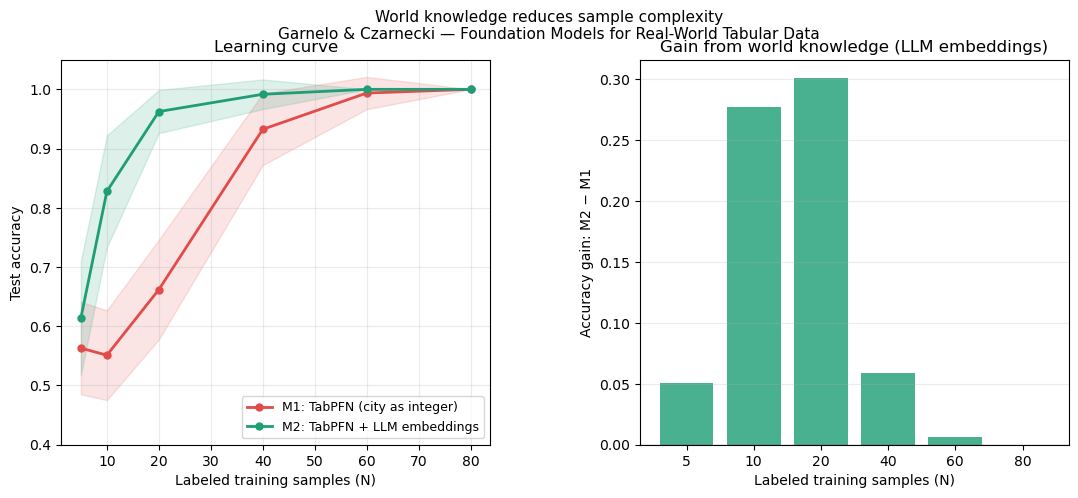


── Summary ──
     N        M1        M2       gap
     5     0.563     0.614    +0.051
    10     0.551     0.828    +0.277
    20     0.662     0.963    +0.301
    40     0.933     0.992    +0.059
    60     0.994     1.000    +0.006
    80     1.000     1.000    +0.000


In [1]:
"""
MVP Experiment: Proving that world knowledge embedding reduces sample complexity.

Paper: Garnelo & Czarnecki — Developing Foundation Models for Real-World Tabular Data

Claim: A model that understands the semantic meaning of categorical variables
needs far fewer labeled examples than one that treats them as arbitrary symbols.

Two models:
  M1 — TabPFN with city label-encoded as integer (city = arbitrary symbol)
  M2 — TabPFN with city replaced by 384-dim LLM embedding (city = meaning)

Key design decisions:
  - TabPFNClassifier() instantiated ONCE per model, outside the loop
  - .fit() called every repeat (necessary — different split each time)
  - M2 uses only the 384-dim embedding, no noise columns (they carry zero signal)
  - M1 uses integer-encoded city + 2 noise columns
  - 20 cities keeps feature count manageable for TabPFN on CPU

Expected result:
  - Low N (5–20):  M2 >> M1  (LLM knows London ~ Tokyo ~ expensive)
  - High N (60–80): gap closes (M1 eventually figures it out from data)

Install:
  pip install tabpfn sentence-transformers scikit-learn numpy pandas matplotlib
"""

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────
# 1. DATASET
# ─────────────────────────────────────────────
# 20 cities, balanced 10/10, spread across regions so the model
# cannot cheat by learning "continent = expensive".
# The only reliable signal is the city name itself.

CITIES = {
    "London":        1,
    "New York":      1,
    "Tokyo":         1,
    "Singapore":     1,
    "Zurich":        1,
    "Sydney":        1,
    "Oslo":          1,
    "Dubai":         1,
    "San Francisco": 1,
    "Hong Kong":     1,

    "Kraków":        0,
    "Manila":        0,
    "Cairo":         0,
    "Lagos":         0,
    "Bogotá":        0,
    "Dhaka":         0,
    "Jakarta":       0,
    "Warsaw":        0,
    "Lima":          0,
    "Nairobi":       0,
}


def build_dataset(seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for city, expensive in CITIES.items():
        for _ in range(5):   # 5 rows per city = 100 rows total
            rows.append({
                "city":         city,
                "pop_millions": rng.uniform(0.5, 22),   # pure noise
                "gdp_index":    rng.uniform(0.2, 1.0),  # pure noise
                "expensive":    expensive,
            })
    df = pd.DataFrame(rows)
    print(f"Dataset: {len(df)} rows | {df['city'].nunique()} cities | "
          f"{df['expensive'].mean():.0%} expensive")
    return df


# ─────────────────────────────────────────────
# 2. EMBEDDING CACHE
# ─────────────────────────────────────────────

def build_embedding_cache(city_names):
    """
    Embed every city name once with sentence-transformers.
    Returns a dict: city_name -> 384-dim numpy vector.
    The ST model is loaded here and never again.
    """
    from sentence_transformers import SentenceTransformer
    print("Loading sentence-transformer (once)...")
    st = SentenceTransformer("all-MiniLM-L6-v2")
    vecs = st.encode(city_names, show_progress_bar=False)
    cache = dict(zip(city_names, vecs))
    print(f"  {len(cache)} cities embedded at {vecs.shape[1]} dims\n")
    return cache


# ─────────────────────────────────────────────
# 3. FEATURE BUILDERS
# ─────────────────────────────────────────────

def features_m1(df, le):
    """
    M1 features: integer-encoded city + 2 noise columns.
    City is an opaque number — TabPFN has no idea what it means.
    """
    city_int = df["city"].map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    ).values.reshape(-1, 1)
    numeric = df[["pop_millions", "gdp_index"]].values
    return np.hstack([city_int, numeric])   # shape: (n, 3)


def features_m2(df, embed_cache):
    """
    M2 features: 384-dim LLM city embedding only.
    No noise columns — they carry zero signal and would bloat the feature space.
    TabPFN sees that London and Tokyo are close, Kraków and Manila are close,
    and the two clusters are far apart.
    """
    return np.stack([embed_cache[c] for c in df["city"]])  # shape: (n, 384)


# ─────────────────────────────────────────────
# 4. EXPERIMENT
# ─────────────────────────────────────────────

def run_experiment(n_samples_list, n_repeats=20, seed=0):
    df = build_dataset()
    embed_cache = build_embedding_cache(list(CITIES.keys()))

    # Label encoder fitted on all cities (stable across splits)
    le = LabelEncoder().fit(list(CITIES.keys()))

    # ── Instantiate TabPFN ONCE per model — weights loaded here, never again ──
    from tabpfn import TabPFNClassifier
    clf_m1 = TabPFNClassifier()
    clf_m2 = TabPFNClassifier()
    print("TabPFN classifiers ready.\n")

    results = {n: {"m1": [], "m2": []} for n in n_samples_list}
    rng = np.random.default_rng(seed)
    total_calls = len(n_samples_list) * n_repeats * 2
    call_num = 0
    t_start = time.time()

    for n in n_samples_list:
        print(f"\nN={n:4d} samples ({n_repeats} repeats)")
        print(f"  {'Rep':>4}  {'Model':>6}  {'Time':>6}  {'Acc':>6}  "
              f"{'Total':>8}  {'ETA':>8}")
        print(f"  {'-'*52}")

        for rep in range(n_repeats):
            idx = rng.choice(len(df), size=n, replace=False)
            mask = np.zeros(len(df), dtype=bool)
            mask[idx] = True
            X_train = df[mask].drop("expensive", axis=1).reset_index(drop=True)
            y_train = df[mask]["expensive"].values
            X_test  = df[~mask].drop("expensive", axis=1).reset_index(drop=True)
            y_test  = df[~mask]["expensive"].values

            if len(np.unique(y_train)) < 2:
                print(f"  {rep+1:>4}  skipped (only one class in train)")
                continue

            for key, clf, feat_fn, feat_args in [
                ("m1", clf_m1, features_m1, (X_train, le)),
                ("m2", clf_m2, features_m2, (X_train, embed_cache)),
            ]:
                call_num += 1
                print(f"  {rep+1:>4}  {key.upper():>6}  running...",
                      end="\r", flush=True)

                t0 = time.time()
                # .fit() called every repeat (new split) — constructor NOT called again
                clf.fit(feat_fn(*feat_args), y_train)

                test_args = (X_test, le) if key == "m1" else (X_test, embed_cache)
                preds = clf.predict(feat_fn(*test_args))

                t_call  = time.time() - t0
                acc     = accuracy_score(y_test, preds)
                t_total = time.time() - t_start
                eta     = (t_total / call_num) * (total_calls - call_num)

                print(f"  {rep+1:>4}  {key.upper():>6}  {t_call:>5.1f}s  "
                      f"{acc:>6.3f}  {t_total:>7.1f}s  {eta:>7.1f}s")
                results[n][key].append(acc)

        m1 = np.mean(results[n]["m1"]) if results[n]["m1"] else float("nan")
        m2 = np.mean(results[n]["m2"]) if results[n]["m2"] else float("nan")
        print(f"  → N={n}: M1={m1:.3f}  M2={m2:.3f}  gap={m2-m1:+.3f}")

    t_total = time.time() - t_start
    print(f"\nDone in {t_total:.1f}s ({t_total/60:.1f} min)")
    return results


# ─────────────────────────────────────────────
# 5. PLOT
# ─────────────────────────────────────────────

def plot_results(results, n_samples_list):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.subplots_adjust(wspace=0.35)

    c1, c2 = "#E24B4A", "#1D9E75"

    m1_means = [np.mean(results[n]["m1"]) for n in n_samples_list]
    m2_means = [np.mean(results[n]["m2"]) for n in n_samples_list]
    m1_stds  = [np.std(results[n]["m1"])  for n in n_samples_list]
    m2_stds  = [np.std(results[n]["m2"])  for n in n_samples_list]

    # Left: learning curves
    ax1.plot(n_samples_list, m1_means, "o-", color=c1, lw=2, ms=5,
             label="M1: TabPFN (city as integer)")
    ax1.plot(n_samples_list, m2_means, "o-", color=c2, lw=2, ms=5,
             label="M2: TabPFN + LLM embeddings")
    ax1.fill_between(n_samples_list,
                     np.array(m1_means) - np.array(m1_stds),
                     np.array(m1_means) + np.array(m1_stds),
                     alpha=0.15, color=c1)
    ax1.fill_between(n_samples_list,
                     np.array(m2_means) - np.array(m2_stds),
                     np.array(m2_means) + np.array(m2_stds),
                     alpha=0.15, color=c2)
    ax1.set_xlabel("Labeled training samples (N)")
    ax1.set_ylabel("Test accuracy")
    ax1.set_title("Learning curve")
    ax1.legend(fontsize=9)
    ax1.set_ylim(0.4, 1.05)
    ax1.grid(alpha=0.25)

    # Right: gap (M2 - M1)
    gaps = [m - b for m, b in zip(m2_means, m1_means)]
    bar_colors = [c2 if g >= 0 else c1 for g in gaps]
    ax2.bar(range(len(n_samples_list)), gaps, color=bar_colors, alpha=0.8)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_xticks(range(len(n_samples_list)))
    ax2.set_xticklabels(n_samples_list)
    ax2.set_xlabel("Labeled training samples (N)")
    ax2.set_ylabel("Accuracy gain: M2 − M1")
    ax2.set_title("Gain from world knowledge (LLM embeddings)")
    ax2.grid(alpha=0.25, axis="y")

    fig.suptitle(
        "World knowledge reduces sample complexity\n"
        "Garnelo & Czarnecki — Foundation Models for Real-World Tabular Data",
        fontsize=11
    )
    plt.savefig("tabfm_mvp_results.png", dpi=150, bbox_inches="tight")
    print("Saved: tabfm_mvp_results.png")
    plt.show()


# ─────────────────────────────────────────────
# 6. ENTRY POINT
# ─────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("TabFM MVP: World knowledge reduces sample complexity")
    print("=" * 60)
    print()

    N_LIST  = [5, 10, 20, 40, 60, 80]
    REPEATS = 20

    results = run_experiment(N_LIST, n_repeats=REPEATS)
    plot_results(results, N_LIST)

    print("\n── Summary ──")
    print(f"{'N':>6}  {'M1':>8}  {'M2':>8}  {'gap':>8}")
    for n in N_LIST:
        m1 = np.mean(results[n]["m1"])
        m2 = np.mean(results[n]["m2"])
        print(f"{n:>6}  {m1:>8.3f}  {m2:>8.3f}  {m2-m1:>+8.3f}")

In [ ]:
print("hello")